# EV Battery Defacts Analysis


### 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy import stats

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('ev_battery_qc_dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
df.info()
display(df.head())

Dataset Shape: (20000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell_ID                   20000 non-null  object 
 1   Batch_ID                  20000 non-null  object 
 2   Production_Line           20000 non-null  object 
 3   Shift                     20000 non-null  object 
 4   Supplier                  20000 non-null  object 
 5   Ambient_Temp_C            19400 non-null  float64
 6   Anode_Overhang_mm         20000 non-null  float64
 7   Electrolyte_Volume_ml     20000 non-null  float64
 8   Internal_Resistance_mOhm  20000 non-null  float64
 9   Capacity_mAh              20000 non-null  float64
 10  Retention_50Cycle_Pct     20000 non-null  float64
 11  Defect_Type               3501 non-null   object 
 12  Inspector_Comment         1667 non-null   object 
 13  QC_Grade                  20000 no

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


### 2. Data Cleaning

In [2]:
# Handle missing values in Ambient_Temp_C
ambient_temp_missing_pct = df['Ambient_Temp_C'].isnull().mean() * 100
print(f"Missing values in Ambient_Temp_C: {ambient_temp_missing_pct:.2f}%")

# Impute missing Ambient_Temp_C with the median (to handle potential outliers)
df['Ambient_Temp_C'] = df['Ambient_Temp_C'].fillna(df['Ambient_Temp_C'].median())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Fill nulls in Defect_Type and Inspector_Comment with 'None'
df['Defect_Type'] = df['Defect_Type'].fillna('None')
df['Inspector_Comment'] = df['Inspector_Comment'].fillna('No Comment')

# Convert categorical variables to categorical type for memory efficiency
cat_cols = ['Production_Line', 'Shift', 'Supplier', 'Defect_Type', 'QC_Grade']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("Data cleaning completed.")

Missing values in Ambient_Temp_C: 3.00%
Number of duplicate rows: 0
Data cleaning completed.


### 3. Exploratory Data Analysis (EDA)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\600184817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='QC_Grade', palette='viridis')


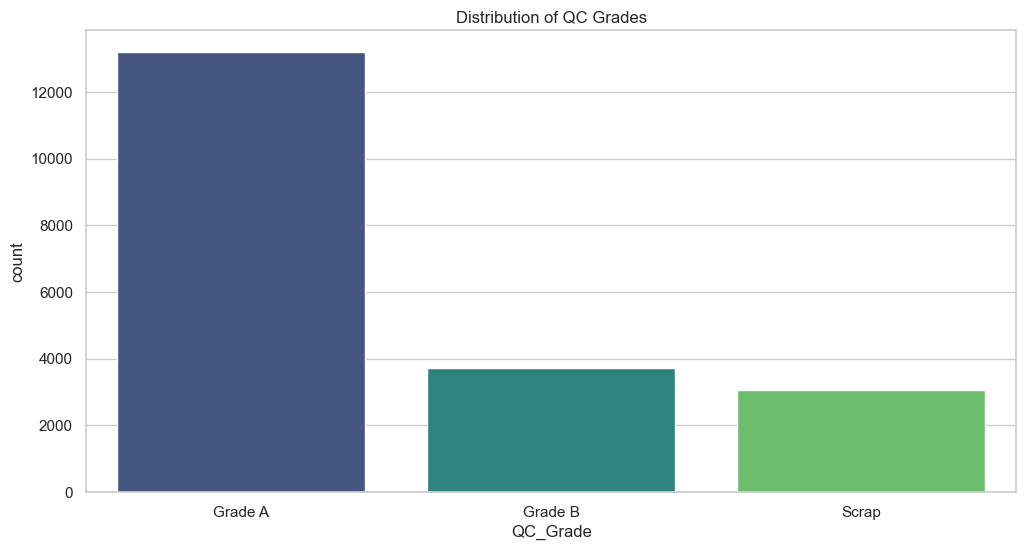

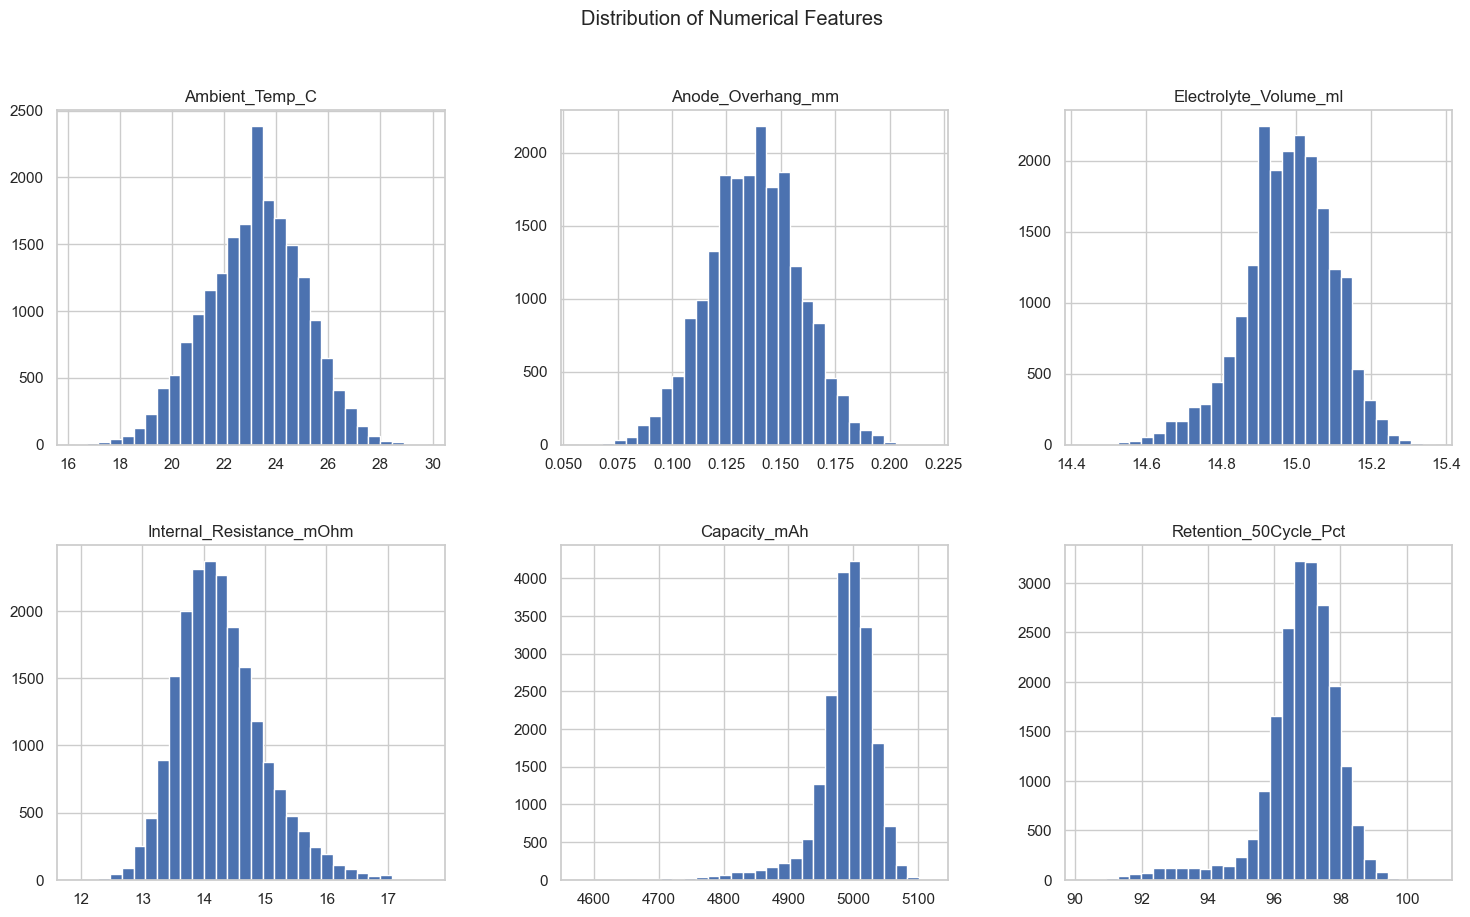

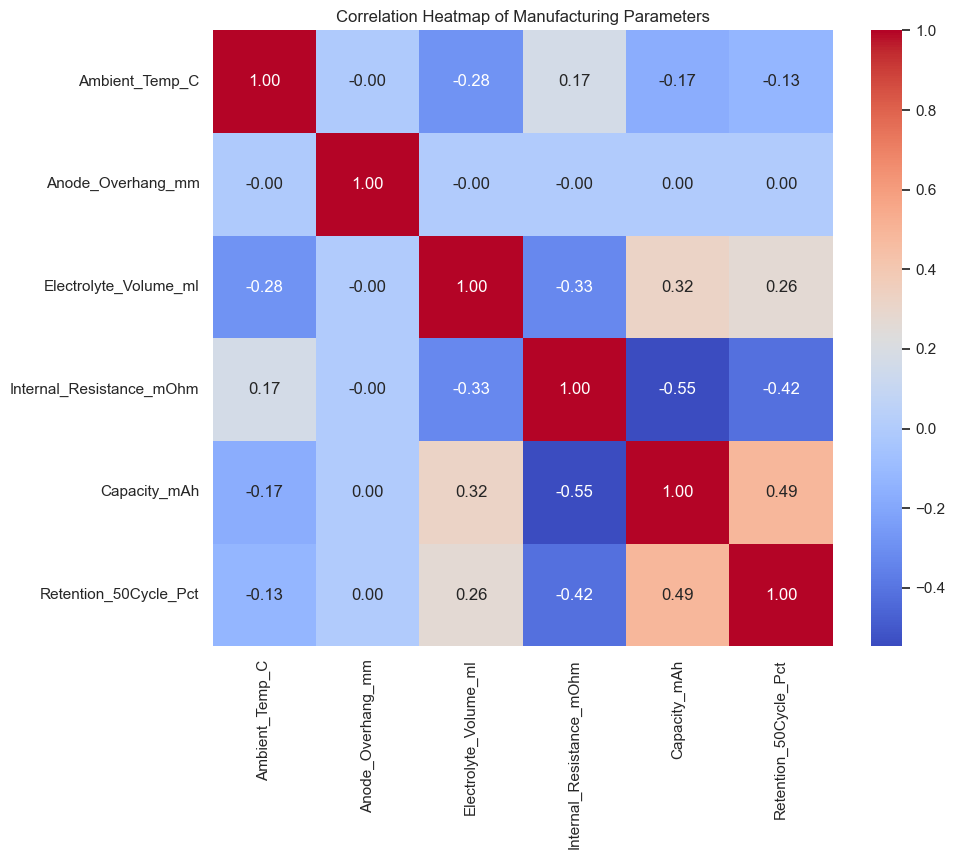

In [3]:
# QC_Grade Distribution
sns.countplot(data=df, x='QC_Grade', palette='viridis')
plt.title('Distribution of QC Grades')
plt.show()

# Distribution of Numerical Features
num_cols = ['Ambient_Temp_C', 'Anode_Overhang_mm', 'Electrolyte_Volume_ml', 
            'Internal_Resistance_mOhm', 'Capacity_mAh', 'Retention_50Cycle_Pct']
df[num_cols].hist(bins=30, layout=(2, 3), figsize=(18, 10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Manufacturing Parameters')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\1294712932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='QC_Grade', y=col, ax=axes[i//3, i%3], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\1294712932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='QC_Grade', y=col, ax=axes[i//3, i%3], palette='Set2')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\1294712932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='QC_Grade', y=col, ax=axes[i//3, i%3], palette='Set2')
C:\User

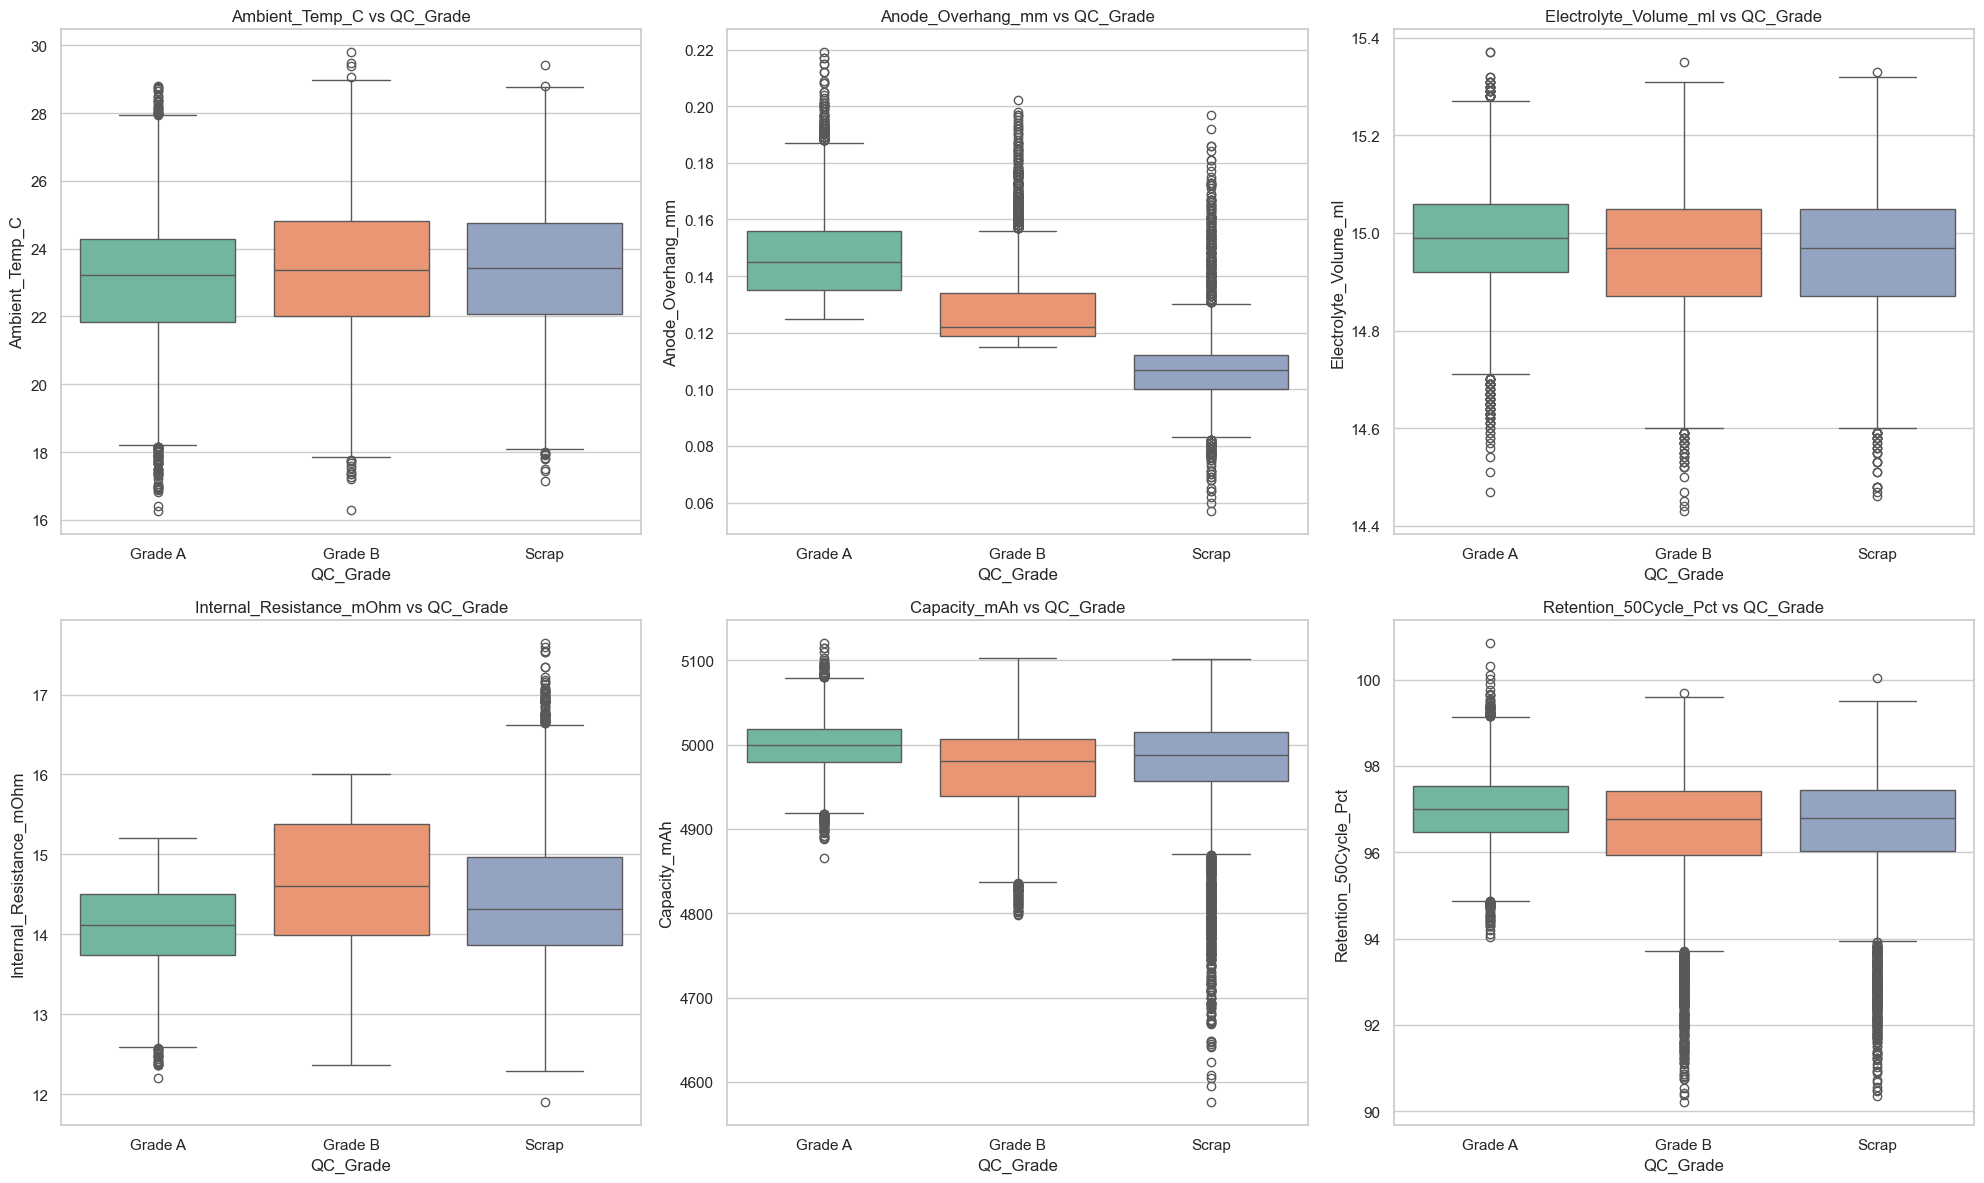

In [4]:
# Relationships between features and QC_Grade
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='QC_Grade', y=col, ax=axes[i//3, i%3], palette='Set2')
    axes[i//3, i%3].set_title(f'{col} vs QC_Grade')
plt.tight_layout()
plt.show()

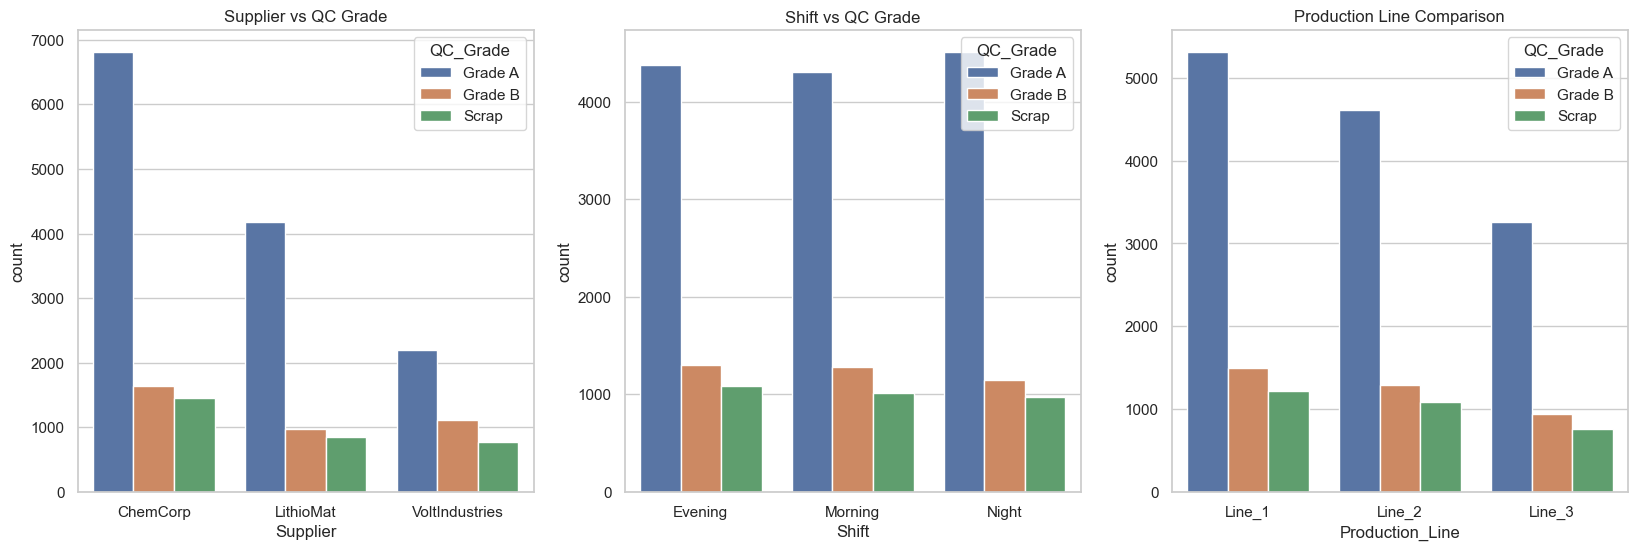

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\250777699.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defect_rates = df.groupby('Supplier')['QC_Grade'].apply(lambda x: (x == 'Scrap').mean()).reset_index()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\250777699.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=defect_rates, x='Supplier', y='Scrap_Rate', palette='Reds_r')


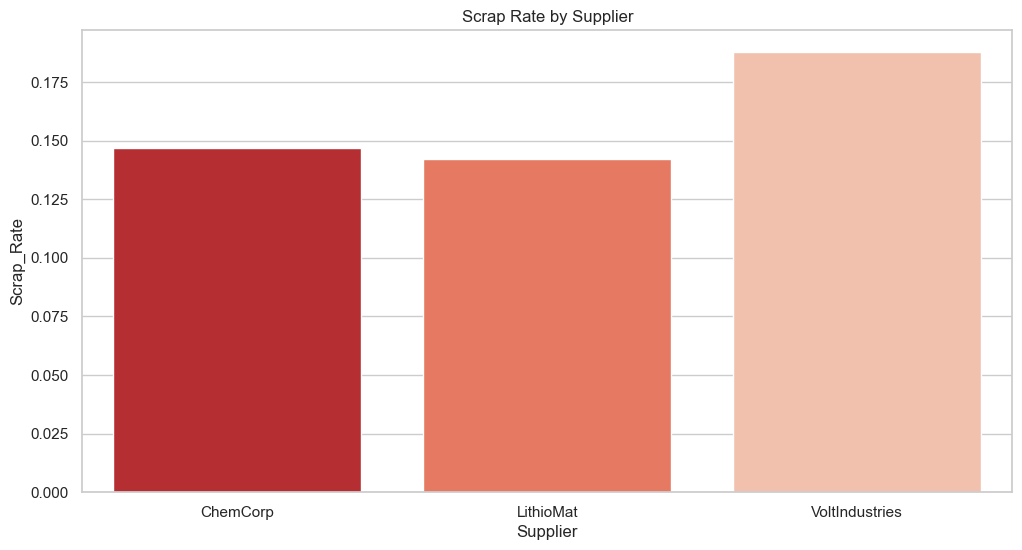

In [5]:
# Supplier, Shift, and Production Line Comparisons
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df, x='Supplier', hue='QC_Grade', ax=axes[0])
axes[0].set_title('Supplier vs QC Grade')

sns.countplot(data=df, x='Shift', hue='QC_Grade', ax=axes[1])
axes[1].set_title('Shift vs QC Grade')

sns.countplot(data=df, x='Production_Line', hue='QC_Grade', ax=axes[2])
axes[2].set_title('Production Line Comparison')

plt.show()

# Calculate Defect Rate (Scrap) per Supplier
defect_rates = df.groupby('Supplier')['QC_Grade'].apply(lambda x: (x == 'Scrap').mean()).reset_index()
defect_rates.columns = ['Supplier', 'Scrap_Rate']
sns.barplot(data=defect_rates, x='Supplier', y='Scrap_Rate', palette='Reds_r')
plt.title('Scrap Rate by Supplier')
plt.show()

### 4. Feature Engineering

In [6]:
# Encode categorical variables for modeling
le = LabelEncoder()
df_encoded = df.copy()

categorical_features = ['Production_Line', 'Shift', 'Supplier']
for col in categorical_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Target variable: QC_Grade (Scrap=0, Grade B=1, Grade A=2)
df_encoded['QC_Grade_Num'] = le.fit_transform(df_encoded['QC_Grade'])

print("Encoding completed.")

Encoding completed.


### 5. Root Cause Analysis (Causal Analysis)

#### Hypothesis Formulation
We hypothesize that higher **Ambient_Temp_C** affects **Electrolyte_Volume_ml** (due to evaporation or viscosity changes during filling), which in turn increases **Internal_Resistance_mOhm**, leading to lower **Capacity_mAh** and ultimately a poorer **QC_Grade**.

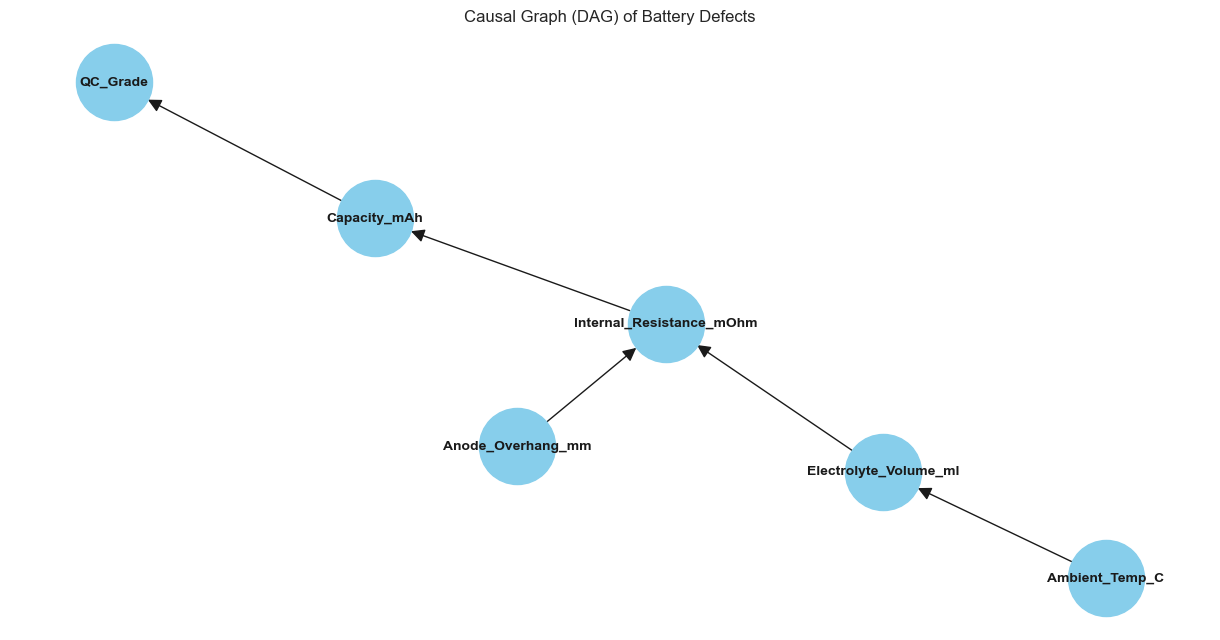

In [7]:
# Build a causal graph (DAG)
G = nx.DiGraph()
edges = [
    ('Ambient_Temp_C', 'Electrolyte_Volume_ml'),
    ('Electrolyte_Volume_ml', 'Internal_Resistance_mOhm'),
    ('Internal_Resistance_mOhm', 'Capacity_mAh'),
    ('Capacity_mAh', 'QC_Grade'),
    ('Anode_Overhang_mm', 'Internal_Resistance_mOhm')
]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_weight="bold", arrows=True, arrowsize=20)
plt.title("Causal Graph (DAG) of Battery Defects")
plt.show()

In [8]:
# Statistical testing of relationships
corr_temp_vol, _ = stats.pearsonr(df['Ambient_Temp_C'], df['Electrolyte_Volume_ml'])
corr_vol_res, _ = stats.pearsonr(df['Electrolyte_Volume_ml'], df['Internal_Resistance_mOhm'])
corr_res_cap, _ = stats.pearsonr(df['Internal_Resistance_mOhm'], df['Capacity_mAh'])

print(f"Correlation Ambient_Temp vs Electrolyte_Vol: {corr_temp_vol:.3f}")
print(f"Correlation Electrolyte_Vol vs Internal_Res: {corr_vol_res:.3f}")
print(f"Correlation Internal_Res vs Capacity: {corr_res_cap:.3f}")

Correlation Ambient_Temp vs Electrolyte_Vol: -0.285
Correlation Electrolyte_Vol vs Internal_Res: -0.325
Correlation Internal_Res vs Capacity: -0.547


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22052\849142671.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance, y=importance.index, palette='magma')


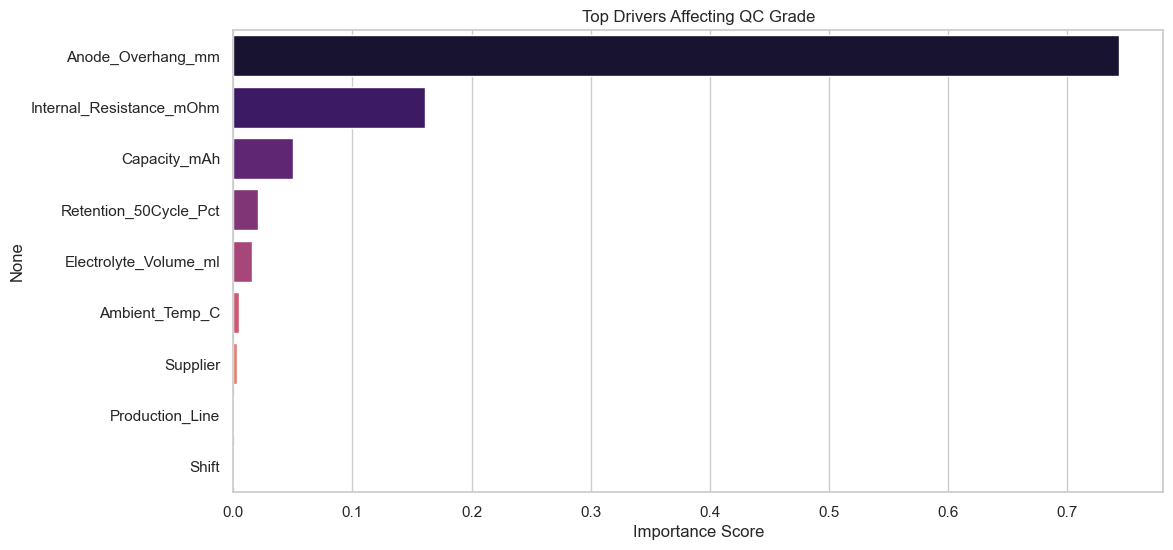

In [9]:
# Feature Importance using RandomForest
X = df_encoded[num_cols + categorical_features]
y = df_encoded['QC_Grade_Num']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importance, y=importance.index, palette='magma')
plt.title('Top Drivers Affecting QC Grade')
plt.xlabel('Importance Score')
plt.show()

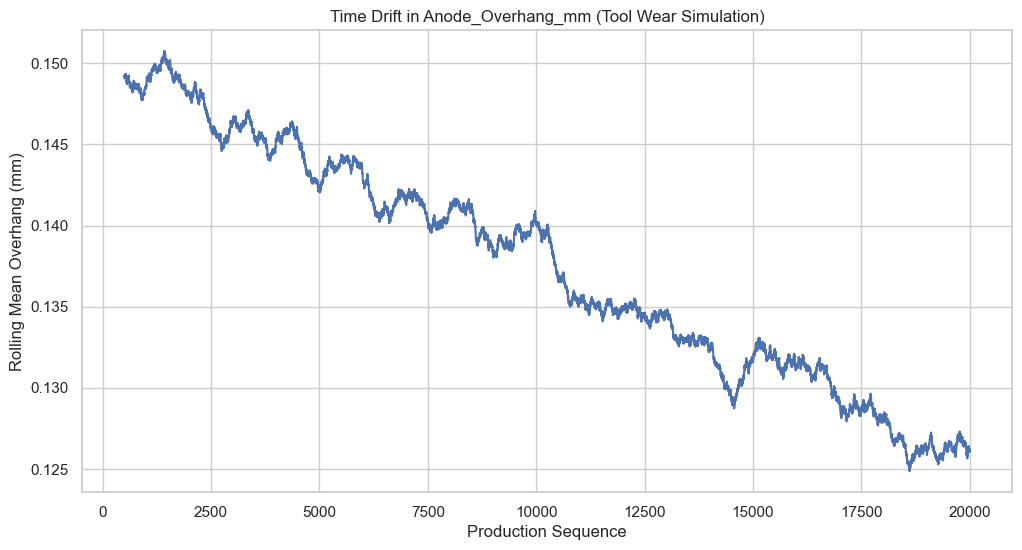

In [10]:
# Time Drift Analysis in Anode_Overhang_mm (Tool Wear Simulation)
# Assuming the data is ordered by production time
df['Rolling_Overhang'] = df['Anode_Overhang_mm'].rolling(window=500).mean()
plt.plot(df['Rolling_Overhang'])
plt.title('Time Drift in Anode_Overhang_mm (Tool Wear Simulation)')
plt.xlabel('Production Sequence')
plt.ylabel('Rolling Mean Overhang (mm)')
plt.show()